In [1]:
using CovidSim_ilm

In [2]:
using StatsBase
using TypedTables
using BenchmarkTools
using Distributions
using YAML
using PrettyPrint
using Plots
using SplitApplyCombine

In [3]:
cd(joinpath(homedir(),"Dropbox/Covid Modeling/Covid-ILM/source"))

In [5]:
# set locale and number of days
locale = 38015
ndays = 180

180

In [5]:
alldat = setup(ndays, [locale]; 
    dovax=true,
    paramdir="../parameters", 
    geofilename="../data/geo2data.csv",
    socialfilename = "socialparams.yml",
    vaccinefilename = "vaccines.yml",
    variantsfilename = "variants.yml"
    );

vaxlist = [:Moderna, :Pfizer, :JnJ]


In [6]:
keys(alldat)

(:dat, :transitionset, :geo, :vaxset, :variants, :vaxschedset, :infectset, :social, :trvec)

In [7]:
alldat.dat

Dict{String, Dict{Int64}} with 4 entries:
  "agegrp_idx" => Dict{Int64, Dict{agegrp, Vector{Int64}}}(38015=>Dict(age80_up…
  "newhistmx"  => Dict{Int64, Array{Int64}}(38015=>[0 0 … 0 0; 0 0 … 0 0; … ; 0…
  "popdat"     => Dict{Int64, Table{NamedTuple{(:pid, :status, :agegrp, :cond, …
  "cumhistmx"  => Dict{Int64, Array{Int64}}(38015=>[0 0 … 0 0; 0 0 … 0 0; … ; 0…

In [8]:
locdat = alldat.dat["popdat"][locale]

Table with 18 columns and 95626 rows:
      pid  status     agegrp   cond        duration  variant  recovday  ⋯
    ┌───────────────────────────────────────────────────────────────────
 1  │ 1    unexposed  age0_19  uninfected  0        base     0         ⋯
 2  │ 2    unexposed  age0_19  uninfected  0        base     0         ⋯
 3  │ 3    unexposed  age0_19  uninfected  0        base     0         ⋯
 4  │ 4    unexposed  age0_19  uninfected  0        base     0         ⋯
 5  │ 5    unexposed  age0_19  uninfected  0        base     0         ⋯
 6  │ 6    unexposed  age0_19  uninfected  0        base     0         ⋯
 7  │ 7    unexposed  age0_19  uninfected  0        base     0         ⋯
 8  │ 8    unexposed  age0_19  uninfected  0        base     0         ⋯
 9  │ 9    unexposed  age0_19  uninfected  0        base     0         ⋯
 10 │ 10   unexposed  age0_19  uninfected  0        base     0         ⋯
 11 │ 11   unexposed  age0_19  uninfected  0        base     0         ⋯
 12 │ 12   u

In [9]:
locdat.vaxrcvd

95626-element Vector{Vector{Symbol}}:
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 ⋮
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]

In [10]:
ages = alldat.dat["agegrp_idx"][locale]

Dict{agegrp, Vector{Int64}} with 5 entries:
  age80_up => [91898, 91899, 91900, 91901, 91902, 91903, 91904, 91905, 91906, 9…
  age40_59 => [49918, 49919, 49920, 49921, 49922, 49923, 49924, 49925, 49926, 4…
  age60_79 => [74303, 74304, 74305, 74306, 74307, 74308, 74309, 74310, 74311, 7…
  age0_19  => [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  23993, 23994, 23995, 23996, 23…
  age20_39 => [24003, 24004, 24005, 24006, 24007, 24008, 24009, 24010, 24011, 2…

In [11]:
alldat.vaxset

Dict{Any, Any} with 3 entries:
  :Moderna => Dict{Symbol, Vaccineparams}(:params=>Vaccineparams(:Moderna, 2, 2…
  :Pfizer  => Dict{Symbol, Vaccineparams}(:params=>Vaccineparams(:Pfizer, 2, 21…
  :JnJ     => Dict{Symbol, Vaccineparams}(:params=>Vaccineparams(:JnJ, 1, 0, 24…

In [14]:
pprintln(alldat.vaxset[:Pfizer])

Vaccineparams(
  name=:Pfizer,
  reqdshots=2,
  delay2ndshot=21,
  halflife=280,
  effectiveness={
                  :first : {:alpha : 0.9, 
                            :base : 0.9, 
                            :delta : 0.84},
                  :full : {:alpha : 0.94, 
                           :base : 0.94, 
                           :delta : 0.88},
                  :booster : {:alpha : 0.94, 
                              :base : 0.94, 
                              :delta : 0.88},
                },
  full_effect_days=14,
  day1_effect=0.5,
  infectfactor=0.75,
)


In [ ]:
pprintln(alldat.vaxset[:Pfizer])

# Load vaccine parameters

In [15]:
# mapping for all vaccines to parameters for each vaccine
vaccines = YAML.load_file("../parameters/vaccines.yml"; dicttype=Dict{Symbol,Any})

Dict{Symbol, Any} with 3 entries:
  :Moderna => Dict{Symbol, Any}(:directory_name=>"moderna", :transition_fname=>…
  :Pfizer  => Dict{Symbol, Any}(:directory_name=>"pfizer", :transition_fname=>"…
  :JnJ     => Dict{Symbol, Any}(:directory_name=>"jnj", :transition_fname=>"jnj…

In [16]:
vaxkeys = keys(vaccines)

KeySet for a Dict{Symbol, Any} with 3 entries. Keys:
  :Moderna
  :Pfizer
  :JnJ

In [17]:
vaccines[:Pfizer]

Dict{Symbol, Any} with 3 entries:
  :directory_name   => "pfizer"
  :transition_fname => "pfizer_transition.yml"
  :infect_fname     => "pfizer_spread.yml"

In [18]:
vaxlist

3-element Vector{Symbol}:
 :Moderna
 :Pfizer
 :JnJ

### Other vaccine parameters

In [19]:
vax = :Moderna
v = YAML.load_file(joinpath("../parameters","vaccine_parameters",vaccines[vax][:directory_name],
        vaccines[vax][:infect_fname]), dicttype=Dict{Symbol, Any})
pprintln(v)

{
  :day1_effect : 0.5,
  :reqdshots : 2,
  :halflife : 280,
  :name : "Moderna",
  :delay2ndshot : 21,
  :full_effect_days : 14,
  :infectfactor : 0.75,
  :effectiveness : {
                     :first : {:alpha : 0.92, 
                               :base : 0.92, 
                               :delta : 0.85},
                     :full : {:alpha : 0.95, 
                              :base : 0.95, 
                              :delta : 0.88},
                     :booster : {:alpha : 0.95, 
                                 :base : 0.95, 
                                 :delta : 0.88},
                   },
}


In [20]:
vaxset = CovidSim_ilm.build_vaxset("vaccines.yml", paramdir="../parameters")

vaxlist = [:Moderna, :Pfizer, :JnJ]


Dict{Any, Any} with 3 entries:
  :Moderna => Dict{Symbol, Vaccineparams}(:params=>Vaccineparams(:Moderna, 2, 2…
  :Pfizer  => Dict{Symbol, Vaccineparams}(:params=>Vaccineparams(:Pfizer, 2, 21…
  :JnJ     => Dict{Symbol, Vaccineparams}(:params=>Vaccineparams(:JnJ, 1, 0, 24…

### Vaccination Schedule

In [21]:
vxschedset = CovidSim_ilm.build_vaxschedset()

Dict{Symbol, Vaxsched} with 1 entry:
  :us1 => Vaxsched(Dict{Symbol, Vaxinclude}(:Moderna=>Vaxinclude(0.3, 450000, 0…

In [22]:
pprintln(vxschedset[:us1])

Vaxsched(
  vaxesincluded={
                  :Moderna : Vaxinclude(
                               mix=0.3,
                               doses=450000,
                               pct2ndshot=0.85,
                               alternate=["Pfizer", 
                                          "JnJ"],
                               booster=false,
                             ),
                  :Pfizer : Vaxinclude(
                              mix=0.55,
                              doses=500000,
                              pct2ndshot=0.85,
                              alternate=["Moderna", 
                                         "JnJ"],
                              booster=false,
                            ),
                  :JnJ : Vaxinclude(
                           mix=0.15,
                           doses=125000,
                           pct2ndshot=0.0,
                           alternate=["Pfizer", 
                                      "Moderna"],
           

In [ ]:
asched = first(keys(vxschedset))

In [ ]:
targetpct=0.65
pattern=  [0.0, 
          0.02, 
          0.05, 
          0.1, 
          0.15, 
          0.19, 
          0.21, 
          0.16, 
          0.08, 
          0.03, 
          0.01, 
          0.0]

In [ ]:
sum(pattern)

In [ ]:
vxschedset[asched].dayrange

In [ ]:
sum([vxschedset[asched].pctfunc(i) for i in vxschedset[asched].dayrange])

In [ ]:
plot(vxschedset[asched].dayrange, [vxschedset[asched].pctfunc(i) for i in vxschedset[asched].dayrange],size=(600,300))

# Give some shots

In [ ]:
peeps = 1000:1999
cnt = length(peeps)
day_ctr[:day] = 555  # must be in the range of the schedule
vaccinate!(locdat, vxschedset, peeps, vaxset)

In [ ]:
vaxlist

In [ ]:
@Select(vaxstatus, vaxday, vaxrcvd)(locdat)[peeps]

In [ ]:
filt_vaccinated = findall(last.(locdat.vaxrcvd) .!= :none)

In [ ]:
@Select(vaxstatus, vaxday, vaxrcvd)(locdat)[filt_vaccinated]

#### Reset the give shots test

In [ ]:
locdat.vaxstatus[peeps] = fill(:none, cnt)
locdat.vaxday[peeps] = fill([0], cnt)
locdat.vaxrcvd[peeps] = fill([:none], cnt)

# Create a seed case

In [6]:
seed_1_6 = seed_case_gen(1, [0,3,3,0,0], 1, nil, :base, agegrps)

(::CovidSim_ilm.var"#runcase#74"{CovidSim_ilm.var"#runcase#73#75"{Int64, Vector{Int64}, Int64, condition, Symbol, NTuple{5, agegrp}}}) (generic function with 1 method)

# Run a simulation

In [7]:
n_days = 180
locale = 38015
model = buildsim(n_days, locale);

In [10]:
popdat, series = runsim(model; 
            runcases=[seed_1_6], 
            dovariant=false,
            dovax=false
            );

*** seed day 1: 6 nil to 38015
(idxtime, vaxtime, sprtime, trtime, histtime) = (0.026611456999999988, 0, 0.317115087, 0.29624049999999996, 0.27077062000000013)


In [11]:
locdat = popdat[locale]

Table with 18 columns and 95626 rows:
      pid  status     agegrp   cond        duration  variant  recovday  ⋯
    ┌───────────────────────────────────────────────────────────────────
 1  │ 1    recovered  age0_19  mild        14       base     93        ⋯
 2  │ 2    unexposed  age0_19  uninfected  0        base     0         ⋯
 3  │ 3    unexposed  age0_19  uninfected  0        base     0         ⋯
 4  │ 4    unexposed  age0_19  uninfected  0        base     0         ⋯
 5  │ 5    unexposed  age0_19  uninfected  0        base     0         ⋯
 6  │ 6    recovered  age0_19  nil         9        base     109       ⋯
 7  │ 7    unexposed  age0_19  uninfected  0        base     0         ⋯
 8  │ 8    recovered  age0_19  mild        14       base     140       ⋯
 9  │ 9    recovered  age0_19  sick        14       base     160       ⋯
 10 │ 10   unexposed  age0_19  uninfected  0        base     0         ⋯
 11 │ 11   recovered  age0_19  mild        14       base     102       ⋯
 12 │ 12   r

In [13]:
countmap(locdat.status)

Dict{status, Int64} with 4 entries:
  unexposed  => 17403
  recovered  => 73225
  dead       => 1384
  infectious => 3614

In [14]:
countmap(locdat.status)

Dict{status, Int64} with 4 entries:
  unexposed  => 17403
  recovered  => 73225
  dead       => 1384
  infectious => 3614

In [15]:
virus_outcome(series, locale, base=:pop)

Dict{Symbol, Float64} with 4 entries:
  :infectious => 0.0377931
  :dead       => 0.0144731
  :recovered  => 0.765744
  :unexposed  => 0.18199

# Plot results

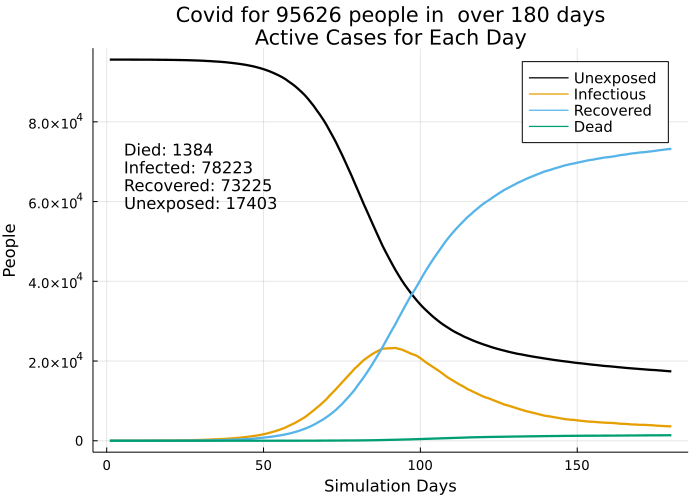

In [16]:
cumplot(series, locale)

Note that the orangle line labeled Infectious that shows the number of infected people is *not* what you see in newspaper accounts. In this plot Infectious shows the net infected people: Some people got sick today. Some people get better: they're not infectious any more--they recovered and are on the blue line. Sadly, some people died--they're not infectious either--they're dead and are on the green line. Newspaper tracking shows the new active infections of each day--who got sick today? The next day, if no one new got sick the line would be at zero--even though the people who got sick aren't better yet. So, the newspaper line goes up and down faster. Yet another approach is to show the cumulative number of infected people: This keeps going up until no one new gets infected--then the line is high but levels off. This is the least common way to show the data.

## Run simulation with full vaccination schedule

In [17]:
seed_1_6 = seed_case_gen(1, [0,3,3,0,0], 1, nil, :base, agegrps)

(::CovidSim_ilm.var"#runcase#74"{CovidSim_ilm.var"#runcase#73#75"{Int64, Vector{Int64}, Int64, condition, Symbol, NTuple{5, agegrp}}}) (generic function with 1 method)

In [18]:
n_days = 360
locale = 38015
model = buildsim(n_days, locale;
            dovax=true);


In [20]:

popdat, series = runsim(model; 
    dovax=true, 
    dovariant=false,
    runcases=[seed_1_6]);

*** seed day 1: 6 nil to 38015
(idxtime, vaxtime, sprtime, trtime, histtime) = (0.06103700500000001, 0.019888122999999966, 0.1842171820000008, 0.09417053900000007, 0.8125174120000004)


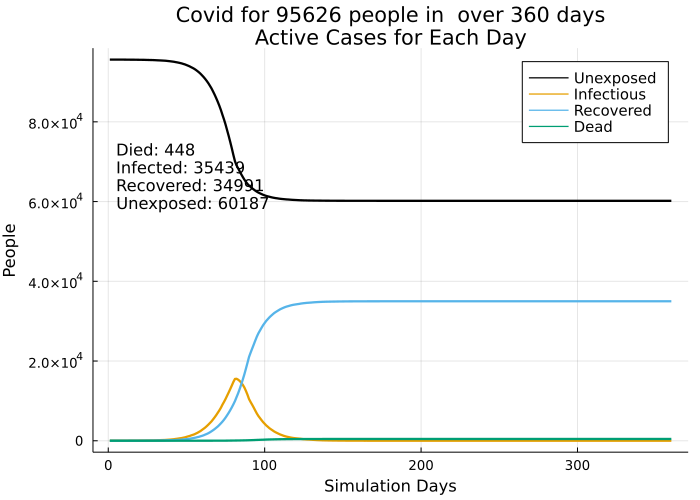

In [21]:
cumplot(series, locale)

In [22]:
locdat = popdat[locale]
vaxcols = @Select(vaxrcvd, vaxstatus)(locdat)

Table with 2 columns and 95626 rows:
      vaxrcvd     vaxstatus
    ┌──────────────────────
 1  │ [:Pfizer]   first
 2  │ [:Moderna]  first
 3  │ [:Moderna]  first
 4  │ [:Moderna]  first
 5  │ [:Moderna]  first
 6  │ [:JnJ]      full
 7  │ [:Moderna]  first
 8  │ [:JnJ]      full
 9  │ [:Pfizer]   first
 10 │ [:Pfizer]   first
 11 │ [:Pfizer]   first
 12 │ [:Moderna]  first
 13 │ [:Moderna]  first
 14 │ [:Pfizer]   first
 15 │ [:Moderna]  first
 16 │ [:Pfizer]   first
 17 │ [:Pfizer]   first
 ⋮  │     ⋮           ⋮

In [23]:
map2series

(unexposed = 1:6, infectious = 7:12, recovered = 13:18, dead = 19:24, nil = 25:30, mild = 31:36, sick = 37:42, severe = 43:48, totinfected = 49:54, Pfizer = 55:60, Moderna = 61:66, JnJ = 67:72, totvaccinated = 73:78, base = 79:84, alpha = 85:90, delta = 91:96, omicron = 97:102)

In [25]:
any(series[38015][:cum][:, map2series[:Pfizer][6]] .!= 0)

true

In [ ]:
pfizer2shots = sum(map(v -> (first(v) == :Pfizer) & (length(v) == 2) ? 2 
            : 0, vaxcols.vaxrcvd))
pfizer1shots = sum(map(v -> (first(v) == :Pfizer) & (length(v) == 1) ? 1 
            : 0, vaxcols.vaxrcvd))

peoplepfizer2 = sum(map(v -> (first(v) == :Pfizer) & (length(v) == 2) ? 1 
            : 0, vaxcols.vaxrcvd))
peoplepfizer1 = sum(map(v -> (first(v) == :Pfizer) & (length(v) == 1) ? 1 
            : 0, vaxcols.vaxrcvd))

moderna2shots = sum(map(v -> (first(v) == :Moderna) & (length(v) == 2) ? 2 
            : 0, vaxcols.vaxrcvd))
moderna1shots = sum(map(v -> (first(v) == :Moderna) & (length(v) == 1) ? 1 
            : 0, vaxcols.vaxrcvd))

peoplemoderna2 = sum(map(v -> (first(v) == :Moderna) & (length(v) == 2) ? 1 
            : 0, vaxcols.vaxrcvd))
peoplemoderna1 = sum(map(v -> (first(v) == :Moderna) & (length(v) == 1) ? 1 
            : 0, vaxcols.vaxrcvd))

peoplejnj = jnjshots = sum(map(v -> (first(v) == :JnJ) & (length(v) == 1) ? 1 
            : 0, vaxcols.vaxrcvd))

peopleatleast1shot = (peoplepfizer2 + peoplepfizer1 + peoplemoderna2 + peoplemoderna1 +
                    peoplejnj)

peoplefull = count(vaxcols.vaxstatus .== :full) 

@show pfizer2shots, pfizer1shots
@show peoplepfizer2, peoplepfizer1

@show moderna2shots, moderna1shots
@show peoplemoderna2, peoplemoderna1

@show jnjshots

@show peopleatleast1shot, peoplefull

In [ ]:
count(vaxcols.vaxstatus .== :full)

In [ ]:
count(vaxcols.vaxstatus .== :first)

## Test a social distancing case

In [26]:
sd1 = sd_gen(startday = 55, comply=0.9, cf=(.2,1.0), tf=(.18,.6), name=:mod_80, include_ages=[])    

(::CovidSim_ilm.var"#runcase#105"{CovidSim_ilm.var"#runcase#104#106"{Int64, Float64, Tuple{Float64, Float64}, Tuple{Float64, Float64}, Symbol, Vector{Any}}}) (generic function with 1 method)

In [27]:
sd1_end = sd_gen(startday = 90, comply=0.0, cf=(.2,1.5), tf=(.18,.6), name=:mod_80, include_ages=[])

(::CovidSim_ilm.var"#runcase#105"{CovidSim_ilm.var"#runcase#104#106"{Int64, Float64, Tuple{Float64, Float64}, Tuple{Float64, Float64}, Symbol, Vector{Any}}}) (generic function with 1 method)

In [29]:
popdat, series = runsim(model; runcases=[seed_1_6, sd1, sd1_end]);

*** seed day 1: 6 nil to 38015
(idxtime, vaxtime, sprtime, trtime, histtime) = (0.08363511100000005, 0, 0.4578554739999997, 0.41218162299999994, 0.54219641)


In [30]:
virus_outcome(series, locale, base=:pop)

Dict{Symbol, Float64} with 4 entries:
  :infectious => 0.0659549
  :dead       => 0.0185933
  :recovered  => 0.793623
  :unexposed  => 0.121829

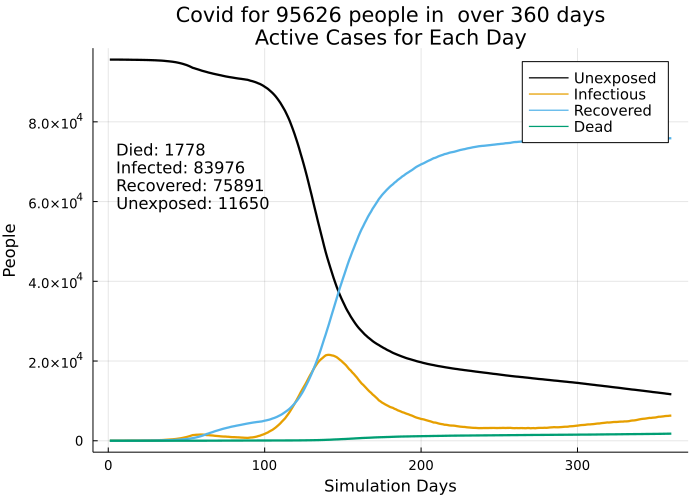

In [31]:
cumplot(series, locale)

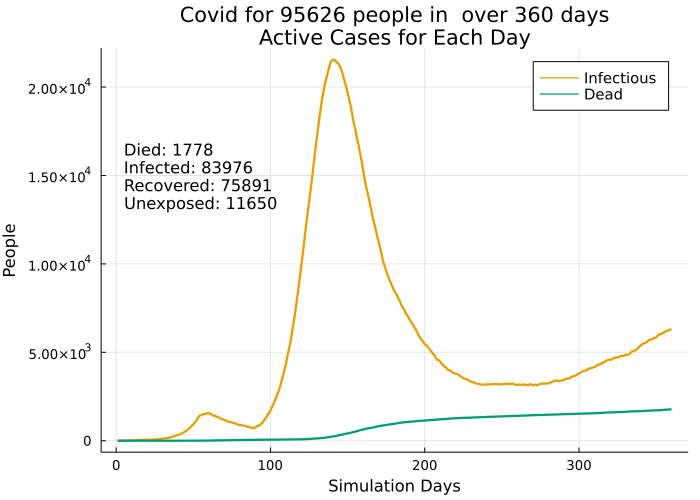

In [32]:
cumplot(series, locale,[:infectious, :dead])

In [33]:
outdat = popdat[locale]
all(outdat.sdcomply .== :none)

true

## Social distancing only among those age40_59, age60_79, age80_plus

In [34]:
sdolder = sd_gen(startday = 55, comply=0.9, cf=(.2,1.0), tf=(.18,.6), name=:mod_80, 
    include_ages=[age40_59, age60_79, age80_up])    

(::CovidSim_ilm.var"#runcase#105"{CovidSim_ilm.var"#runcase#104#106"{Int64, Float64, Tuple{Float64, Float64}, Tuple{Float64, Float64}, Symbol, Vector{agegrp}}}) (generic function with 1 method)

In [35]:
sdolder_end = sd_gen(startday = 90, comply=0.0, cf=(.2,1.5), tf=(.18,.6), name=:mod_80, 
    include_ages=[age40_59, age60_79, age80_up])    

(::CovidSim_ilm.var"#runcase#105"{CovidSim_ilm.var"#runcase#104#106"{Int64, Float64, Tuple{Float64, Float64}, Tuple{Float64, Float64}, Symbol, Vector{agegrp}}}) (generic function with 1 method)

In [36]:
popdat, series = runsim(model;  
                    runcases=[seed_1_6, sdolder, sdolder_end]);

*** seed day 1: 6 nil to 38015
(idxtime, vaxtime, sprtime, trtime, histtime) = (0.07793336000000001, 0, 0.516968491, 0.4852596330000006, 0.5353307900000001)


In [37]:
olderdat = popdat[locale]

sd = findall(olderdat.sdcomply .!= :none)

@Select(agegrp, sdcomply)(olderdat[sd])

Table with 2 columns and 0 rows:
     agegrp  sdcomply
   ┌─────────────────

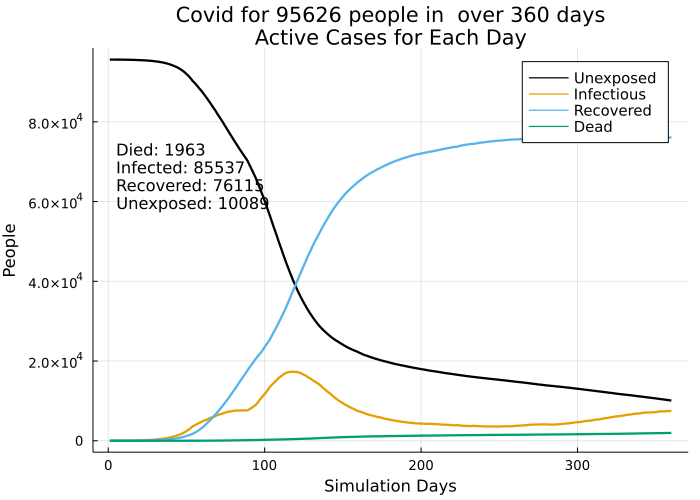

In [38]:
cumplot(series, locale)

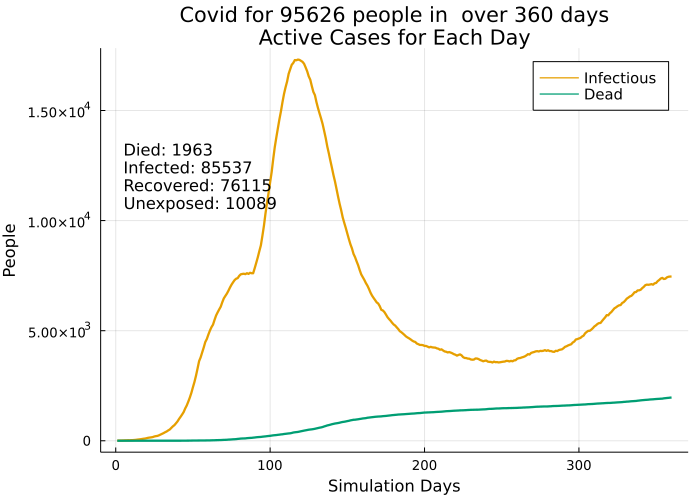

In [39]:
cumplot(series, locale, [:infectious, :dead])

## Social Distancing starts with everyone and then the younger folks party

In [40]:
sdyoung_end = sd_gen(startday = 90, comply=0.0, cf=(.2,1.5), tf=(.18,.6), name=:mod_80, 
    include_ages=[age0_19, age20_39])    

(::CovidSim_ilm.var"#runcase#105"{CovidSim_ilm.var"#runcase#104#106"{Int64, Float64, Tuple{Float64, Float64}, Tuple{Float64, Float64}, Symbol, Vector{agegrp}}}) (generic function with 1 method)

In [41]:
popdat, series = runsim(model; 
                    runcases=[seed_1_6, sd1, sdyoung_end]);

*** seed day 1: 6 nil to 38015
(idxtime, vaxtime, sprtime, trtime, histtime) = (0.07994508999999998, 0, 0.16859228899999995, 0.15574324899999997, 0.516818494)


In [42]:
mixdat = popdat[locale]

sd = findall(mixdat.sdcomply .!= :none)
young = findall((mixdat.agegrp .== age0_19) .| (mixdat.agegrp .== age20_39))
sd_young_idx = intersect(sd, young)
old = findall((mixdat.agegrp .== age40_59) .| (mixdat.agegrp .== age60_79) .| (mixdat.agegrp .== age80_up));

In [43]:
youngtab = Table(mixdat[young])
count(youngtab.sdcomply .== :none)

49917

In [44]:
oldtab = Table(mixdat[old])
count(oldtab.sdcomply .!= :none)

41097

In [45]:
typeof(mixdat.agegrp)

Vector{agegrp} (alias for Array{agegrp, 1})

In [46]:
mixdat = popdat[locale]

Table with 18 columns and 95626 rows:
      pid  status     agegrp   cond        duration  variant  recovday  ⋯
    ┌───────────────────────────────────────────────────────────────────
 1  │ 1    unexposed  age0_19  uninfected  0        base     0         ⋯
 2  │ 2    unexposed  age0_19  uninfected  0        base     0         ⋯
 3  │ 3    unexposed  age0_19  uninfected  0        base     0         ⋯
 4  │ 4    recovered  age0_19  severe      14       base     240       ⋯
 5  │ 5    unexposed  age0_19  uninfected  0        base     0         ⋯
 6  │ 6    recovered  age0_19  nil         9        base     302       ⋯
 7  │ 7    recovered  age0_19  sick        14       base     226       ⋯
 8  │ 8    unexposed  age0_19  uninfected  0        base     0         ⋯
 9  │ 9    recovered  age0_19  mild        14       base     225       ⋯
 10 │ 10   recovered  age0_19  mild        14       base     295       ⋯
 11 │ 11   unexposed  age0_19  uninfected  0        base     0         ⋯
 12 │ 12   u

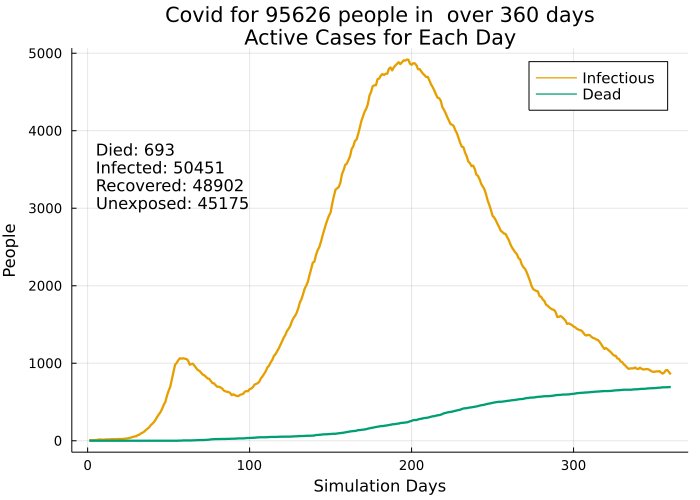

In [47]:
cumplot(series, locale, [:infectious, :dead])

In [48]:
@Select(status, agegrp, cond, sdcomply)(locdat)

Table with 4 columns and 95626 rows:
      status     agegrp   cond        sdcomply
    ┌─────────────────────────────────────────
 1  │ unexposed  age0_19  uninfected  none
 2  │ unexposed  age0_19  uninfected  none
 3  │ unexposed  age0_19  uninfected  none
 4  │ unexposed  age0_19  uninfected  none
 5  │ unexposed  age0_19  uninfected  none
 6  │ unexposed  age0_19  uninfected  none
 7  │ unexposed  age0_19  uninfected  none
 8  │ unexposed  age0_19  uninfected  none
 9  │ unexposed  age0_19  uninfected  none
 10 │ unexposed  age0_19  uninfected  none
 11 │ unexposed  age0_19  uninfected  none
 12 │ unexposed  age0_19  uninfected  none
 13 │ unexposed  age0_19  uninfected  none
 14 │ unexposed  age0_19  uninfected  none
 15 │ unexposed  age0_19  uninfected  none
 16 │ unexposed  age0_19  uninfected  none
 17 │ unexposed  age0_19  uninfected  none
 ⋮  │     ⋮         ⋮         ⋮          ⋮

In [ ]:
ages = alldat.dat["agegrp_idx"][locale]

In [ ]:
include_ages = [age0_19, age20_39]

In [ ]:
union((ages[i] for i in include_ages)...)

In [ ]:
locdat.sdcomply[collect(1:5:95000)] .= :test

In [ ]:
incase_idx = findall(locdat.sdcomply .== :test)

In [ ]:
byage_idx = intersect(incase_idx, union((ages[i] for i in include_ages)...))

In [ ]:
@btime locdat.status;

In [ ]:
statuscol = locdat.status
@btime statuscol;

In [ ]:
nt = (one=1, two=2, three=3)

In [ ]:
@btime nt.one;

In [ ]:
thisone = nt.one
@btime thisone;

# Test History series code